In [1]:
!pip install pillow --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 61.6 MB/s eta 0:00:00
  Attempting uninstall: pillow
    Found existing installation: pillow 11.3.0
    Uninstalling pillow-11.3.0:
      Successfully uninstalled pillow-11.3.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 5.50.0 requires pillow<12.0,>=8.0, but you have pillow 12.2.0 which is incompatible.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Python Imaging Library (PIL)의 Image 모듈을 불러옴. 이미지 파일을 열고 조작하는 데 사용함.
from PIL import Image

# Matplotlib의 pyplot 모듈을 plt 별칭으로 불러옴. 시각화에 사용함.
import matplotlib.pyplot as plt

# PyTorch 핵심 라이브러리를 불러옴.
import torch

# 신경망 레이어(nn) 모듈을 불러옴.
import torch.nn as nn

# 옵티마이저(optim) 모듈을 불러옴.
import torch.optim as optim

# TorchVision 라이브러리를 불러옴. (이미지 변환 및 데이터셋 등에 사용)
import torchvision

# 학습에 사용할 장치(Device)를 설정함. CUDA(GPU)가 사용 가능하면 'cuda'를, 아니면 'cpu'를 선택함.
dvc = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
# # 이미지 파일 열고 전처리 Pytorch 텐서 변환 함수
# def image_to_tensor(image_filepath, image_dimension=128):
#     img = Image.open(image_filepath).convert('RGB')

#     #  디버깅 확인용
#     plt.figure()
#     plt.title(image_filepath)
#     plt.imshow(img)

#     # 이미지의 최대해상도가 지정된 크기(image_dimension)보다 작거나 같으면 >> 원본 사용
#     if max(img.size) <= image_dimension:
#          img_size = max(img.size)
#     # 이미지의 최대 해상도가 지정된 크기보다 크면 >> 지정된 크기 사용
#     else:
#          img_size = image_dimension

#     # 이미지를 텐서로 변환하기 위해 변환 파이프라인 정의 (Compose)
#     torch_transformation = torchvision.transforms.Compose([
#         torchvision.transforms.Resize(img_size),   # 이미지 사이즈 조정
#         torchvision.transforms.ToTensor(),          # 픽셀 값 범위 [0,1] 정규화 (텐서로 압축)
#     ])

#     img = torch_transformation(img).unsqueeze(0)   # 배치 차원(차원 0)

#     return img.to(dvc, torch.float)


In [ ]:
def image_to_tensor(image_filepath, image_dimension=128):
    img = Image.open(image_filepath).convert('RGB')

    #  디버깅 확인용
    plt.figure()
    plt.title(image_filepath)
    plt.imshow(img)

    # 이미지의 최대해상도가 지정된 크기(image_dimension)보다 작거나 같으면 >> 원본 사용
    if max(img.size) <= image_dimension:
         img_size = max(img.size)
    # 이미지의 최대 해상도가 지정된 크기보다 크면 >> 지정된 크기 사용
    else:
         img_size = image_dimension

    # 이미지를 텐서로 변환하기 위해 변환 파이프라인 정의 (Compose)
    torch_transformation = torchvision.transforms.Compose([
        torchvision.transforms.Resize(img_size, interpolation=torchvision.transforms.InterpolationMode.BILINEAR),   # 이미지 사이즈 조정
        torchvision.transforms.CenterCrop(224),
        torchvision.transforms.ToTensor(),          # 픽셀 값 범위 [0,1] 정규화 (텐서로 압축)
        torchvision.transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

    img = torch_transformation(img).unsqueeze(0)   # 배치 차원(차원 0)

    return img.to(dvc, torch.float)

In [ ]:
# # 이미지 파일 열고 전처리 Pytorch 텐서 변환 함수
# def image_to_tensor(image_filepath, image_dimension=128):
#     img = Image.open(image_filepath).convert('RGB')

#     #  디버깅 확인용
#     plt.figure()
#     plt.title(image_filepath)
#     plt.imshow(img)

#     # 이미지의 최대해상도가 지정된 크기(image_dimension)보다 작거나 같으면 >> 원본 사용
#     if max(img.size) <= image_dimension:
#          img_size = max(img.size)
#     # 이미지의 최대 해상도가 지정된 크기보다 크면 >> 지정된 크기 사용
#     else:
#          img_size = image_dimension

#     # 이미지를 텐서로 변환하기 위해 변환 파이프라인 정의 (Compose)
#     torch_transformation = torchvision.transforms.Compose([
#         torchvision.transforms.Resize(img_size),   # 이미지 사이즈 조정
#         torchvision.transforms.ToTensor(),          # 픽셀 값 범위 [0,1] 정규화 (텐서로 압축)
#         torchvision.transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
#     ])

#     img = torch_transformation(img).unsqueeze(0).to(dvc, torch.float)   # 배치 차원(차원 0)

#     img = img * 255 # [0,1] >> [0, 255]

#     # N, C, H, W >> C를 RGB << BGR로 변경
#     img = img[:, [2,1,0], :, :]    # channel 순서 변경 (RGB >> BGR) (VGG 오리지널 특징)

#     # vgg_mean = torch.tensor([103.939, 116.779, 123.68]).view(1,3,1,1).to(dvc, torch.float)
#     # img = img - vgg_mean
#     # 평균 값을 빼는 이유: [0, 255]
#     # 0을 중앙에 놓기 위해서 >> 평균 빼서 [-127, 127] 사이에 0을 기준으로 만들기 위해
#     # view(1,3,1,1) 브로드캐스팅 1: 배치 크기, 3: 채널/BGR, 1: h, 1: w
#     # 원본 이미지 텐서 (1,3,128,128) 그런데 (1,3,1,1) >> 브로드캐스팅 (1,3,128,128) 자동 복사

#     return img


In [ ]:
# 역전처리 함수
def tensor_to_image(tensor):
    # VGG 전처리 (0-255, BGR, Mean 차감) 텐서 >> RGB ([0, 1])
    img = tensor.clone().detach().squeeze(0).cpu()

    # VGG mean 더하기 (BGR 순서대로)
    # vgg_mean = torch.tensor([103.939, 116.779, 123.68]).view(1,3,1,1).to(dvc)
    # img = img + vgg_mean

    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

    img = img * std + mean

    # BGR >> RGB 뒤집기
    img = img[:, [2,1,0], :, :]

    # 255로 나누어 [0,1]로 나누기
    # img = img / 255.0

    # 범위 고정 [0,1] 벗어난 값 처리
    img = img.clamp_(0, 1)

    return img.squeeze(0).cpu().numpy().transpose(1,2,0)



/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 4367 (\N{HANGUL CHOSEONG KHIEUKH}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 4453 (\N{HANGUL JUNGSEONG EO}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 4535 (\N{HANGUL JONGSEONG MIEUM}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 4369 (\N{HANGUL CHOSEONG PHIEUPH}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 4466 (\N{HANGUL JUNGSEONG YU}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 4368 (\N{HANGUL CHOSEONG THI

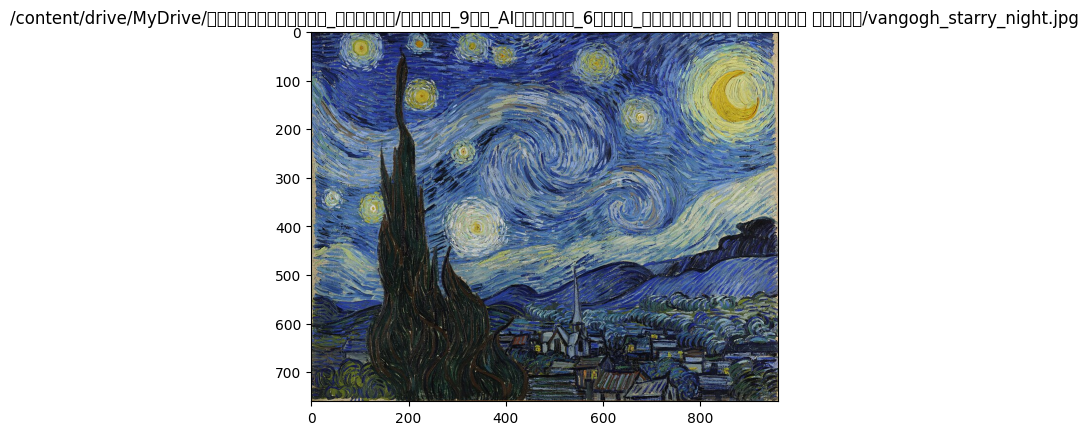

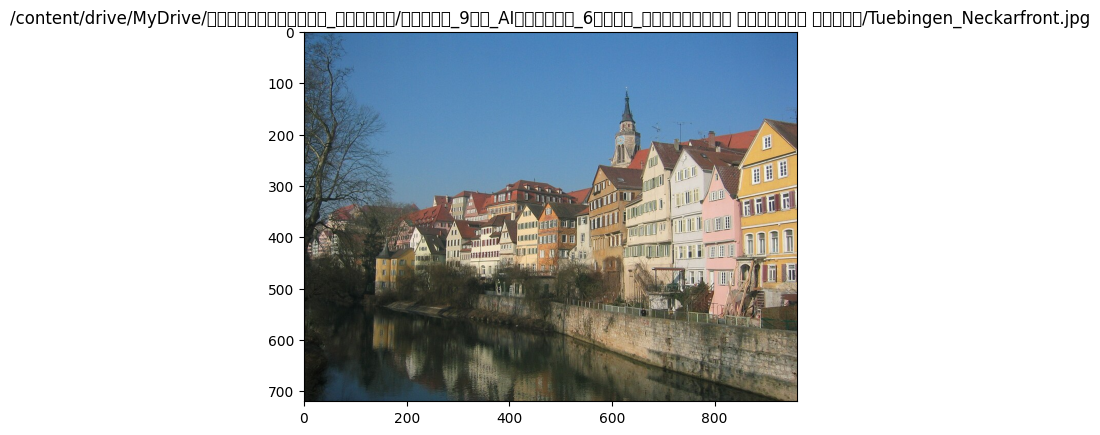

In [ ]:
# 스타일 이미지 파일을 열고 텐서로 변환했음.
style_image = image_to_tensor('/content/drive/MyDrive/컴퓨터비전_응용/강의_9기_AI응용_6차시_신경망 스타일 전이/vangogh_starry_night.jpg')
# 콘텐츠 이미지 파일을 열고 텐서로 변환했음.
content_image = image_to_tensor('/content/drive/MyDrive/컴퓨터비전_응용/강의_9기_AI응용_6차시_신경망 스타일 전이/Tuebingen_Neckarfront.jpg')

In [ ]:
# Gram Matrix
def gram_matrix(ip):
    num_batch, num_channels, height, width = ip.size()
    # 입력 텐서의 4가지 차원 (배치, 채널 수, 높이, 너비) 추출

    # 텐서의 공간 차원(높이 * 너비) >> 하나의 벡터 (평탄화 flatten)
    # 텐서 크기(num_batch, num_channels, width * height)
    featrues = ip.view(num_batch, num_channels, height * width)

    # 배치 행렬 곱셈 (b,c, h*w) @ (b, h*w, c) >> (b,c,c)
    gram = torch.bmm(featrues, featrues.transpose(1, 2))

    # 정규화 (채널 수 * 높이 * 너비)
    # 요소의 총 개수로 나누어 스케일 조정
    return gram.div(num_channels * height * width)

In [ ]:
# 사전 학습된 모델
vgg19 = torchvision.models.vgg19(pretrained=True).to(dvc)

print(vgg19)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padd

In [ ]:
vgg19 = vgg19.features
# vgg 19 model의 특징만 가져다 쓸래

In [ ]:
# 신경망 활용한 스타일 트랜스퍼 특징 추출 작업에서 필수적 단계
# 가져온 사전 학습 모델의 모든 파라미터 고정(freezing)
for param in vgg19.parameters():
    param.requires_grad_(False)

In [ ]:
len(vgg19)

37

In [ ]:
# pooling  작업 (maxpool >> avgpool 교체)
# >> pooling 영역에서 maxpool 대신 avgpool 사용시, 더 부드러운 특징맵 생성
# >> 스타일 전송품질 높아짐

# 합성곱 레이어의 인덱스 저장할 빈 리스트 생성
conv_indices = []

# vgg19 특징 추출 레이어들 (sequential module) 순회
for i in range(len(vgg19)):
    if vgg19[i]._get_name() == 'MaxPool2d':
       vgg19[i] = nn.AvgPool2d(kernel_size=vgg19[i].kernel_size,
                     stride=vgg19[i].stride,
                     padding=vgg19[i].padding)

    if vgg19[i]._get_name() == 'Conv2d':
        conv_indices.append(i)
        # 해당 레이어의 인덱스(i) >> 리스트에 추가함

conv_indices = dict(enumerate(conv_indices, 1))
# 수집된 conv_indices 리스트에서 1부터 순서를 매긴 dict() 생성
# 예: {1:0, 2:2,....}

print(vgg19)
print()
print(conv_indices)

Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU(inplace=True)
  (4): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReLU(inplace=True)
  (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): ReLU(inplace=True)
  (9): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): ReLU(inplace=True)
  (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): ReLU(inplace=True)
  (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (15): ReLU(inplace=True)
  (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (17): ReLU(inplace=True)
  (18): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (19): Conv2d(256

In [ ]:
# 실습
# def gram_matrix(ip):
#     num_batch, num_channels, height, width = ip.size()
#     features = ip.view(num_batch, num_channels, height*width)
#     gram = torch.bmm(features, features.transpose(1,2))
#     return gram.div_(num_channels * height * width)

In [ ]:
# # 실습
# vgg19 = torchvision.models.vgg19(pretrained=True).to(dvc)
# vgg19 = vgg19.features
# for param in vgg19.parameters():
#     param.requires_grad_(False)

# conv_inidces = []
# for i in range(len(vgg19)):
#     if vgg19[i] == 'MaxPool2d':
#         vgg19[i] = nn.AvgPool2d(kernel_size=vgg19[i].kernel_size,
#                      stride=vgg19[i].stride,
#                      padding=vgg19[i].padding)
#     if vgg19[i] == 'Conv2d':
#         conv_indices.append(i)

# conv_indices = dict(enumerate(conv_indices, 1)) # 몇번째에 convolution layer가 오는지 순서 표시

# layers = {1: 's', 2:'s', 3:'s', 4: 'sc', 5:'s'}

# vgg_layers = nn.ModuleList(vgg19)
# last_layer_idx = conv_indices[max(conv_indices.keys())]

# vgg_layers_trimmed = vgg_layers[:last_layer_idx+1]

# neural_style_transfer_model = nn.Sequencial(*vgg_layers_trimmed)

In [ ]:
conv_indices.keys()

dict_keys([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16])

clip until the last relevant layer

In [ ]:
# layers = {1: 's', 2:'s', 3:'s', 4: 'sc', 5:'s'}
# s: style loss, c: content loss
layers = {1: 's', 2:'s', 3:'s', 4: 'sc', 5:'sc'}


In [ ]:
# vgg19 모델의 특징 추출기(features) 부분을 nn.ModuleList 변환
# 전체 모델이 완전연결층(fully connected layer)으로 구성된 것 중 불필요한 뒷부분 잘라내고(clip)
# 핵심적인 특징추출기만 남기는 '모델 경량화' 작업(실무)  **중요**

vgg_layers = nn.ModuleList(vgg19)
# print(vgg_layers)

# 이전에 수집한 conv_indices(합성곱 인덱스 딕셔너리)에서 가장 큰 인덱스(가장 깊은 레이어) 찾음
last_layer_idx = conv_indices[max(conv_indices.keys())]
# print(last_layer_idx)   # 34

# vgg 레이어 리스트를 시작부터 마지막 합성곱 레이어까지 자름(+1을 하면 마지막 레이어 포함)
vgg_layers_trimmed = vgg_layers[:last_layer_idx+1]
# print(vgg_layers_trimmed)

# 잘라낸 레이어들을 nn.Sequential 모듈로 묶어서 최종 모델 구성
# 이 모델은 이미지에서 스타일과 콘텐츠 특징 추출하는데 사용
neural_style_transfer_model = nn.Sequential(*vgg_layers_trimmed)

print(neural_style_transfer_model)

Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU(inplace=True)
  (4): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReLU(inplace=True)
  (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): ReLU(inplace=True)
  (9): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): ReLU(inplace=True)
  (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): ReLU(inplace=True)
  (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (15): ReLU(inplace=True)
  (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (17): ReLU(inplace=True)
  (18): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (19): Conv2d(256

In [ ]:
# 최적화 대상 이미지(ip_image)를 콘텐츠 이미지 크기와 동일한 랜덤 노이즈로 초기화
# ip_image = torch.randn(content_image.data.size(), device=dvc) * 255
ip_image = torch.randn(content_image.data.size(), device=dvc)

# vgg_mean 차감
# vgg_mean = torch.tensor([103.939, 116.779, 123.68]).view(1,3,1,1).to(dvc, torch.float)
# ip_image = ip_image - vgg_mean
ip_image.requires_grad_(True)   # 최적화 대상 텐서로 지정(gradient 추적 활성화)

plt.figure()
plt.imshow(tensor_to_image(ip_image.data))
plt.show()

# plt.imshow(ip_image.squeeze(0).cpu().detach().numpy().transpose(1,2,0).clip(0,1))
# 텐서에서 배치차원(0번) 제거, 넘파이 변환 위해 cpu, detach, numpy
# 그런 뒤에 채널 순서 맞춰주고 gpu에서 chw >> hwc 변환, 픽셀값은 [0,1] 클립하여 출력
# plt.show()

IndexError: too many indices for tensor of dimension 3

<Figure size 640x480 with 0 Axes>

In [ ]:
# 실습
# 최적화 대상 이미지 -> 초기 이미지 설정(랜덤 노이즈)
# ip_img = torch.randn(content_image.data.size(), device=dvc)

epoch_number 50
content loss = 947876.875, style loss = 918848929792.0


IndexError: too many indices for tensor of dimension 3

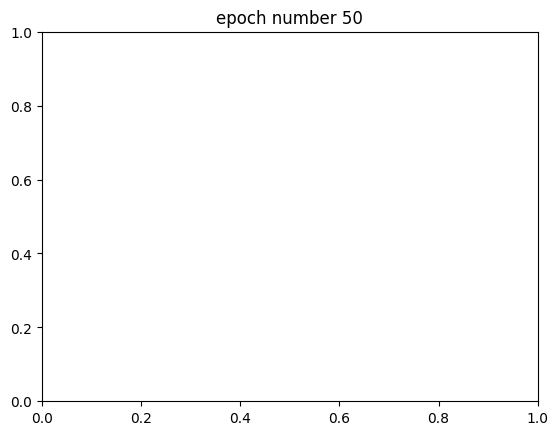

In [ ]:
# 총 최적화 에폭 300
num_epochs = 300

# 스타일 손실에 부여할 가중치(weight) 설정함. 콘텐츠 손실보다 훨씬 크게 설정함
wt_style = 1e5
# 콘텐츠 손실에 부여할 가중치(weight) 설정
wt_content = 1

# 각 에폭별(학습할 때마다) 스타일 손실 저장할 리스트 초기화
style_losses = []
# 각 에폭별(학습할 때마다) 콘텐츠 손실 저장할 리스트 초기화
content_losses = []

# 옵티마이저 정의함. 최적화 대상은 ip_image 뿐이며, Adam을 사용, 학습률(lr) 0.1 설정
opt = optim.Adam([ip_image.requires_grad_()], lr=0.1)

for curr_epoch in range(1, num_epochs+1):
    # ip_image.data.clamp_(0,1)
    # 생성된 이미지(ip_image)의 pixel 값 [0,1] 범위 내로 강제로 유지
    opt.zero_grad()
    # 옵티마이저에 저장된 모든 변화(gradient) 0으로 초기화

    epoch_style_loss = 0
    epoch_content_loss = 0
    # 현재 에폭(학습) 스타일 손실과 콘텐츠 손실 누적 변수를 0으로 초기화

    # 손실 계산할 레이어 인덱스(k) 순회
    for k in layers.keys():
        # layer k가 콘텐츠 손실('c') 계산할 때 포함된 경우
        if 'c' in layers[k]:
            # 콘텐츠 이미지 특징 추출 >> 변화도 계산에서 제외(detach)
            target = neural_style_transfer_model[:conv_indices[k]+1](content_image).detach()
            # 현재 이미지 특징추출
            ip = neural_style_transfer_model[:conv_indices[k]+1](ip_image)
            # 콘텐츠 손실(mse) 계산해서 누적
            epoch_content_loss += torch.nn.functional.mse_loss(ip, target)

        # layer k가 스타일 손실('s') 계산할 때 포함된 경우
        if 's' in layers[k]:
             # 스타일 이미지 특징 추출 >> 변화도 계산에서 제외(detach)
            target = gram_matrix(neural_style_transfer_model[:conv_indices[k]+1](style_image)).detach()
            # 현재 이미지 특징추출
            ip = gram_matrix(neural_style_transfer_model[:conv_indices[k]+1](ip_image))
            # 스타일 손실(mse) 계산해서 누적
            epoch_style_loss += torch.nn.functional.mse_loss(ip, target)

    # 누적된 콘텐츠 손실에 가중치(wt_content) 곱함
    epoch_content_loss *= wt_content

    # 누적된 스타일 손실에 가중치(wt_style) 곱함
    epoch_style_loss *= wt_style

    # 최종 총 손실 계산
    total_loss = epoch_content_loss + epoch_style_loss

    # 역전파 수행, 총 손실에 대한 변화(gradient) 계산
    total_loss.backward()

    # 50 epoch 마다 현재 상태 출력 >> 시각화
    if curr_epoch % 50 == 0:
        print(f'epoch_number {curr_epoch}')
        print(f'content loss = {epoch_content_loss}, style loss = {epoch_style_loss}')
        plt.figure()
        plt.title(f'epoch number {curr_epoch}')

        # 생성된 이미지를 역변환 (clamp, squeeze, numpy, transpose) 시각화
        # plt.imshow(ip_image.data.clamp_(0,1).squeeze(0).cpu().detach().numpy().transpose(1,2,0))

        rgb_image = tensor_to_image(ip_image.data)
        plt.imshow(rgb_image)

        plt.show()

        content_losses.append(epoch_content_loss.item())
        style_losses.append(epoch_style_loss.item())

    opt.step()
    # 옵티마이저 이용 변화도(gradient) 방향으로 이미지 픽셀 값 업데이트

In [ ]:
# # 실습
# # 총 에목 300
# num_epochs = 300
# # 스타일 손실에 부여할 가중치(weight) 설정함. 콘텐츠 손실보다 훨씬 크게 설정함
# wt_style = [1e6/n^2 for n in [64, 128, 256, 512, 512]]
# # 콘텐츠 손실에 부여할 가중치(weight) 설정
# wt_content = 1

# # 각 에폭별(학습할 때마다) 스타일 손실 저장할 리스트 초기화
# style_losses = []
# # 각 에폭별(학습할 때마다) 콘텐츠 손실 저장할 리스트 초기화
# content_losses = []

# # 옵티마이저 정의함. 최적화 대상은 ip_image 뿐이며, Adam을 사용, 학습률(lr) 0.1 설정
# # opt = optim.Adam([ip_image.requires_grad_()], lr=0.1)
# opt = optim.LBFGS([ip_image.requires_grad_()], max_iter=1)

# for curr_epoch in range(1, num_epochs+1):
#     ip_image.data.clamp_(0,1)

#     epoch_style_loss = 0
#     epoch_content_loss = 0

#     for k in layers.keys():
#         if 'c' in layers[k]:
#             target = neural_style_transfer_model[:conv_indices[k+1](style_image)].detach()
#             ip = neural_style_transfer_model[:conv_indices[k+1](ip_image)]
#             epoch_content_loss += torch.nn.functional.mse_loss(ip, target)


In [ ]:
plt.plot(range(50, 300+1, 50), content_losses, label='content_loss')
plt.plot(range(50, 300+1, 50), style_losses, label='style_loss')
plt.legend()
plt.show()

In [ ]:
# 이의 제기 (by s.w.k) 만족 시켜주세요

def total_variation_loss(img):
    # Total variation loss란 인접한 픽셀간 차이값이 너무 크지 않도록 규제
    # 한 픽셀씩 어긋난 픽셀 리스트끼리 빼면 >> 근접 이웃끼리 차이가 한번에 나옴
    # (b, c, h, w)
    w_tv = torch.sum(torch.abs(img[:,:,:,:-1] - img[:,:,:,1:]))
    # 가로방향(w) 인접 픽셀 차이(오른쪽 픽셀 - 왼쪽 픽셀)
    h_tv = torch.sum(torch.abs(img[:,:,:-1,:] - img[:,:,1:,:]))
    #  세로방향(h) 인접 픽셀 차이(아래쪽 픽셀 - 위쪽 픽셀)

    loss = torch.mean(w_tv) + torch.mean(h_tv)
    return loss

In [ ]:
# tv loss  가중치 설정
wt_tv = 1e-5

# 총 최적화 에폭 500
num_epochs = 300

# 스타일 손실에 부여할 가중치(weight) 설정함. 콘텐츠 손실보다 훨씬 크게 설정함
wt_style = 1e6
# 콘텐츠 손실에 부여할 가중치(weight) 설정
wt_content = 1

# 각 에폭별(학습할 때마다) 스타일 손실 저장할 리스트 초기화
style_losses = []
# 각 에폭별(학습할 때마다) 콘텐츠 손실 저장할 리스트 초기화
content_losses = []

# 옵티마이저 정의함. 최적화 대상은 ip_image 뿐이며, Adam을 사용, 학습률(lr) 0.1 설정
opt = optim.Adam([ip_image.requires_grad_()], lr=0.1)

for curr_epoch in range(1, num_epochs+1):
    # ip_image.data.clamp_(0,1)
    # 생성된 이미지(ip_image)의 pixel 값 [0,1] 범위 내로 강제로 유지
    opt.zero_grad()
    # 옵티마이저에 저장된 모든 변화(gradient) 0으로 초기화

    epoch_style_loss = 0
    epoch_content_loss = 0
    # 현재 에폭(학습) 스타일 손실과 콘텐츠 손실 누적 변수를 0으로 초기화

    # 손실 계산할 레이어 인덱스(k) 순회
    for k in layers.keys():
        # layer k가 콘텐츠 손실('c') 계산할 때 포함된 경우
        if 'c' in layers[k]:
            # 콘텐츠 이미지 특징 추출 >> 변화도 계산에서 제외(detach)
            target = neural_style_transfer_model[:conv_indices[k]+1](content_image).detach()
            # 현재 이미지 특징추출
            ip = neural_style_transfer_model[:conv_indices[k]+1](ip_image)
            # 콘텐츠 손실(mse) 계산해서 누적
            epoch_content_loss += torch.nn.functional.mse_loss(ip, target)

        # layer k가 스타일 손실('s') 계산할 때 포함된 경우
        if 's' in layers[k]:
             # 스타일 이미지 특징 추출 >> 변화도 계산에서 제외(detach)
            target = gram_matrix(neural_style_transfer_model[:conv_indices[k]+1](style_image)).detach()
            # 현재 이미지 특징추출
            ip = gram_matrix(neural_style_transfer_model[:conv_indices[k]+1](ip_image))
            # 스타일 손실(mse) 계산해서 누적
            epoch_style_loss += torch.nn.functional.mse_loss(ip, target)

    # 누적된 콘텐츠 손실에 가중치(wt_content) 곱함
    epoch_content_loss *= wt_content

    # 누적된 스타일 손실에 가중치(wt_style) 곱함
    epoch_style_loss *= wt_style

    # tv loss 계산
    tv_loss = total_variation_loss(ip_image)

    # 최종 총 손실 계산
    total_loss = epoch_content_loss + epoch_style_loss + (tv_loss * wt_tv)

    # 역전파 수행, 총 손실에 대한 변화(gradient) 계산
    total_loss.backward()

    # 50 epoch 마다 현재 상태 출력 >> 시각화
    if curr_epoch % 50 == 0:
        print(f'epoch_number {curr_epoch}')
        print(f'content loss = {epoch_content_loss}, style loss = {epoch_style_loss}')
        plt.figure()
        plt.title(f'epoch number {curr_epoch}')

        # 생성된 이미지를 역변환 (clamp, squeeze, numpy, transpose) 시각화
        # plt.imshow(ip_image.data.clamp_(0,1).squeeze(0).cpu().detach().numpy().transpose(1,2,0))

        rgb_image = tensor_to_image(ip_image.data)
        plt.imshow(rgb_image)

        plt.show()

        content_losses.append(epoch_content_loss.item())
        style_losses.append(epoch_style_loss.item())

    opt.step()
    # 옵티마이저 이용 변화도(gradient) 방향으로 이미지 픽셀 값 업데이트

In [ ]:
plt.plot(range(50, 300+1, 50), content_losses, label='content_loss')
plt.plot(range(50, 300+1, 50), style_losses, label='style_loss')
plt.legend()
plt.show()

In [ ]:
# epoch=300 : 픽셀 간 경계를 부드럽게 하기 위해 인접한 픽셀을 계산해서 loss를 줄이기 위해 조절하다가 오히려 노이즈가 되었다.

In [ ]:
# eos